# Import statements

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Visualise

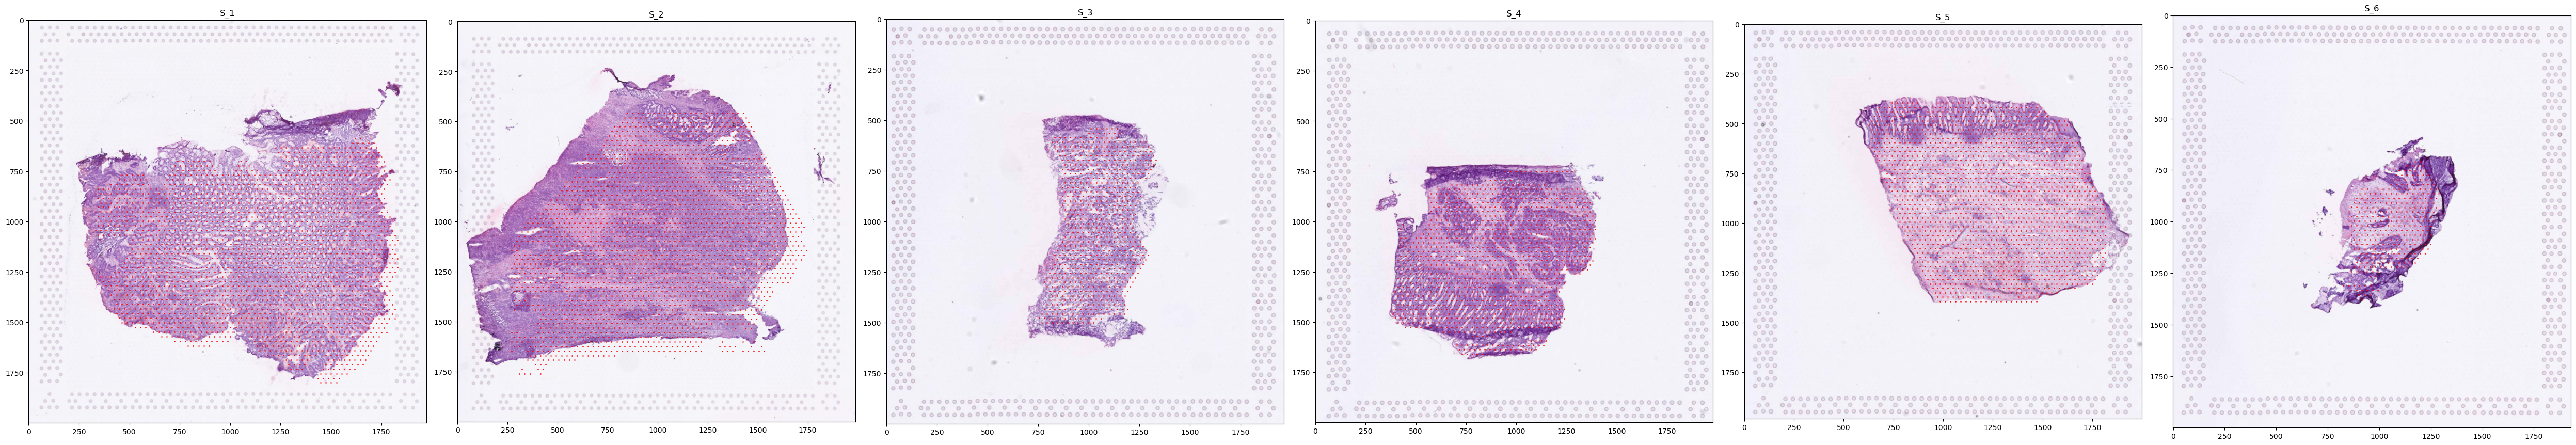

In [3]:
# Visualize Training slides with spot overlays
with h5py.File("elucidata_ai_challenge_data.h5", "r") as h5file:
    train_images = h5file["images/Train"]
    train_spots = h5file["spots/Train"]

    num_train_slides = len(train_images)
    fig, ax = plt.subplots(1, num_train_slides, figsize=(50, 50))
    for i, slide_name in enumerate(train_images.keys()):
        image = np.array(train_images[slide_name])
        spots = np.array(train_spots[slide_name])
        x, y = spots["x"], spots["y"]
    
        ax[i].imshow(image, aspect="equal")
        ax[i].scatter(x, y, color="red", s=1, alpha=0.8)  # Overlay spot locations
        ax[i].set_title(slide_name)
        ax[i].axis()
        
    
    plt.tight_layout()
    plt.show()

In [75]:
def compute_offset(img, bg_thresh=245):
    """
    img: uint8 HxWx3 image
    bg_thresh: above this grayscale value we treat as background
    returns (left, top) pixel offsets of the tissue crop
    """
    # convert to grayscale
    gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
    # mask tissue = pixels darker than bg_thresh
    tissue_mask = gray < bg_thresh
    ys, xs = np.nonzero(tissue_mask)
    top, left = ys.min(), xs.min()
    return left, top

compute_offset(np.array(train_images['1']))

KeyError: 'Unable to synchronously open object (invalid identifier type to function)'

In [273]:
slide_name

'S_6'

In [33]:
def print_h5_structure(name, obj):
    indent = "  " * name.count('/')
    print(f"{indent}{name} ({'Group' if isinstance(obj, h5py.Group) else 'Dataset'})")

with h5py.File("elucidata_ai_challenge_data.h5", "r") as f:
    f.visititems(print_h5_structure)

images (Group)
  images/Test (Group)
    images/Test/S_7 (Dataset)
  images/Train (Group)
    images/Train/S_1 (Dataset)
    images/Train/S_2 (Dataset)
    images/Train/S_3 (Dataset)
    images/Train/S_4 (Dataset)
    images/Train/S_5 (Dataset)
    images/Train/S_6 (Dataset)
spots (Group)
  spots/Test (Group)
    spots/Test/S_7 (Dataset)
  spots/Train (Group)
    spots/Train/S_1 (Dataset)
    spots/Train/S_2 (Dataset)
    spots/Train/S_3 (Dataset)
    spots/Train/S_4 (Dataset)
    spots/Train/S_5 (Dataset)
    spots/Train/S_6 (Dataset)


In [145]:
spots

array([[(1211,  954, 1.03681390e-01, 0.5999859 , 0.20747449, 3.28435957e-03, 7.30703313e-02, 2.36524885e-03, 2.13494103e-01, 5.41370282e-02, 6.83436436e-03, 2.12595154e-03, 4.15884508e-02, 3.13319905e-02, 1.82507998e-02, 1.60477885e-01, 2.33397515e-02, 4.50432609e-01, 1.78264521e+00, 0.14617234, 5.55407855e-01, 1.26410146e-01, 2.68689044e-02, 2.31830815e-01, 0.36267651, 1.17509171e+00, 1.89904201e-01, 5.48785967e-01, 2.61890485e-03, 1.76992091e-02, 2.61124558e-02, 5.03581986e-01, 0.3599661 , 0.27328798, 1.87153093e-01, 3.96244479e-02, 2.24018659e-01),
        (1057, 1177, 4.82122369e-02, 0.19754586, 0.08192514, 7.57904355e-03, 8.72007680e+00, 5.13851797e-04, 1.11266122e-01, 2.71786597e-02, 2.35104708e-04, 1.00019326e-03, 1.21099229e-03, 2.69933755e-02, 1.23053345e-02, 4.25763424e-03, 1.96975045e-02, 1.06898678e-01, 2.77010848e-02, 0.02842615, 1.26462218e-02, 7.80333281e-02, 6.23663250e-02, 1.80419511e-01, 0.1373352 , 8.73148089e-04, 1.71795063e-01, 2.51318922e-04, 6.16878970e-03, 5.944

In [284]:
import pandas as pd

# Open the HDF5 file
with h5py.File("elucidata_ai_challenge_data.h5", "r") as h5file:
    # Access the spots group for training
    train_spots = h5file["spots/Train"]
    
    # Select one slide — for example, 'S_1'
    slide_spots = train_spots["S_2"]
    
    # Convert to a structured NumPy array
    spot_data = slide_spots[:]
    
    # Convert to pandas DataFrame
    df = pd.DataFrame(spot_data)
    pd.set_option('display.max_columns', None)
# Display the table
df.iloc[2179]
df.head()

,x,y,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26,C27,C28,C29,C30,C31,C32,C33,C34,C35
0,1572,1350,1.542454,0.052541,1.415544,0.487771,0.291268,0.000100,0.016733,0.000078,0.000063,9.394451e-06,2.082775e-04,0.001613,0.001874,0.003300,0.000347,0.002442,0.108978,0.182527,0.000517,0.071783,0.012673,1.499562e-01,0.073591,0.112518,0.001375,0.000347,0.000027,0.000156,0.000086,4.929894e-05,0.073729,0.066650,1.158249e-04,0.010423,0.050226
1,480,1555,3.257770,0.057553,1.948030,0.806345,0.484212,0.000077,0.032623,0.000092,0.000063,1.077362e-05,6.593650e-05,0.002476,0.008869,0.001335,0.000295,0.003253,0.011680,0.278251,0.002963,0.017807,0.011321,6.167385e-03,0.061735,0.369384,0.000155,0.000264,0.000043,0.000147,0.001001,1.824790e-06,0.093010,0.067205,2.352456e-02,0.026911,0.052347
2,1467,526,0.081944,0.013208,0.085818,0.271692,1.027989,0.066760,0.009644,0.000291,0.813023,1.159067e-05,4.144451e-07,0.004885,0.000006,0.000524,0.031324,0.151563,0.000050,0.009705,0.067213,0.018052,0.017075,1.737103e-02,0.008209,0.000594,0.000016,0.000005,0.005426,0.000005,0.000914,1.203776e-07,0.010981,0.006998,2.140756e-05,0.000059,0.003903
3,349,1189,5.108457,0.072301,2.773961,1.386638,0.496647,0.000065,0.031599,0.000490,0.000019,1.196985e-05,2.506910e-05,0.003111,0.054066,0.002023,0.000317,0.001279,0.073098,0.255202,0.012740,0.019725,0.021099,1.578076e-02,0.108607,0.104608,0.000097,0.000398,0.000023,0.000365,0.000139,6.238090e-06,0.217229,0.109407,1.024292e-04,0.064159,0.070167
4,401,1280,0.199682,0.014278,0.109534,0.007316,0.028238,0.000008,0.000730,0.000158,0.000249,4.333712e-07,1.079372e-05,0.000193,0.000002,0.000689,0.000137,0.034914,0.008376,0.003537,0.000009,0.002959,0.000046,6.705559e-07,0.006104,0.050896,0.000078,0.000005,0.000019,0.000005,0.000007,3.539291e-04,0.003999,0.006315,8.194072e-07,0.001353,0.000929


In [297]:
df.shape
print(df["y"].min())
print(df["y"].max())
df["y"].min()+((df["y"].max()-df["y"].min())/2)

457
1761


np.float64(1109.0)

In [276]:
df["x"].argmax()

np.int64(2179)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

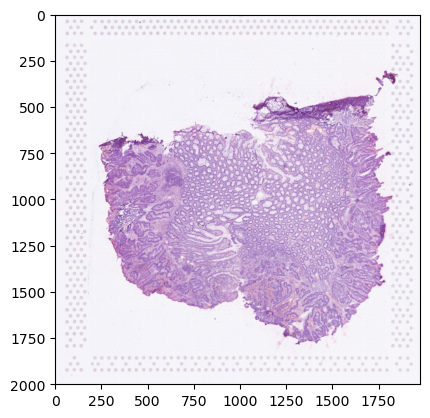

In [85]:
with h5py.File('elucidata_ai_challenge_data.h5', 'r') as f:
    image = f['images/Train/S_1'][()]

# Assume image is in RGB (shape: H x W x 3)
threshold = 240
non_white_mask = np.any(image < threshold, axis=2)

# Get Y indices that contain non-white pixels (i.e., stained tissue)
y_indices = np.where(np.any(non_white_mask, axis=1))[0]

# Top Y index with stained tissue
top_y = y_indices[0] if len(y_indices) > 0 else 0
fig, ax = plt.subplots()

# Plot the image starting from top_y
ax.imshow(image, extent=[0, image.shape[1], image.shape[0], 0])

# Plot the spots (example)
# Assuming 'spots' is an Nx2 array of (x, y) positions
adjusted_spots = spots.copy()
adjusted_spots[:,1] -= top_y  # shift Y

ax.scatter(adjusted_spots[:,0], adjusted_spots[:,1], c='red', s=10)

plt.show()

In [87]:
print(image.shape)

(2000, 1974, 3)


In [143]:
with h5py.File('elucidata_ai_challenge_data.h5', 'r') as file:
    # Access the specific dataset
    obj = file['images/Train/S_1']
    data = obj[:]
    
img = plt.imread()
print(f'{img.shape=}',
      f'{img.min()=}',
      f'{img.max()=}',
      f'{img.mean()=}',
      f'{img.sum()=}',
      sep='\n')

FileNotFoundError: [Errno 2] No such file or directory: 'images/Train/S_1'

In [130]:
with h5py.File('elucidata_ai_challenge_data.h5', 'r') as file:
    # Access the specific dataset
    obj = file['images/Train/S_1']

    if isinstance(obj, h5py.Dataset):
        print("This is a dataset!")
        # Proceed to read the data
        data = obj[:]  # Read the entire dataset
        print(f"Dataset shape: {data.shape}")
    else:
        print("This is NOT a dataset!")
        print(f"Object type: {type(obj)}")

This is a dataset!
Dataset shape: (2000, 1974, 3)


In [132]:
with h5py.File('elucidata_ai_challenge_data.h5', 'r') as file:
    obj = file.get('images/Train/S_1')
    
    if isinstance(obj, h5py.SoftLink):
        print("This is a soft link!")
    elif isinstance(obj, h5py.HardLink):
        print("This is a hard link!")
    else:
        print("This is neither a soft nor hard link.")

This is neither a soft nor hard link.


In [134]:
with h5py.File('elucidata_ai_challenge_data.h5', 'r') as file:
    # Access the dataset
    s1_image = file['images/Train/S_1']
    
    # Read a small portion of the dataset (e.g., first 10 rows and columns)
    data_sample = s1_image[:10, :10, :]  # Read a small 10x10 section of the image
    print(f"Data sample shape: {data_sample.shape}")
    print(f"Data sample: {data_sample}")

Data sample shape: (10, 10, 3)
Data sample: [[[0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]]

 [[0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]]

 [[0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]
  [0.9647059 0.9607843 0.9882353]


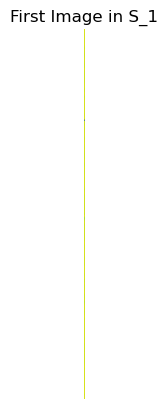

In [135]:
with h5py.File('elucidata_ai_challenge_data.h5', 'r') as file:
    # Access the dataset
    s1_image = file['images/Train/S_1']
    
    # Read a small portion (e.g., the first image in the dataset)
    image_data = s1_image[0, :, :]  # First image (assuming the first dimension is the image index)
    
    # Visualize the image (assuming it's an RGB image)
    plt.imshow(image_data)
    plt.title('First Image in S_1')
    plt.axis('off')  # Turn off the axis labels
    plt.show()

In [285]:
import numpy as np
import h5py

def get_lowest_tissue_y(img, bg_thresh=150):
    """
    Returns the largest y-coordinate (bottom-most) where tissue appears in the image.
    
    Parameters:
        img: RGB image as a NumPy array (HxWx3)
        bg_thresh: background threshold (grayscale)
    
    Returns:
        bottom_y: Integer y-coordinate
    """
    # Convert to grayscale
    gray = np.dot(img[..., :3], [200, 150, 100])

    # Create mask for tissue (darker than background)
    tissue_mask = gray < bg_thresh

    # Get y-coordinates where tissue exists
    ys, _ = np.nonzero(tissue_mask)

    # Return the bottom-most y value (max y)
    return ys.max() if len(ys) > 0 else None

def get_highest_tissue_y(img, bg_thresh=150):
    """
    Returns the largest y-coordinate (bottom-most) where tissue appears in the image.
    
    Parameters:
        img: RGB image as a NumPy array (HxWx3)
        bg_thresh: background threshold (grayscale)
    
    Returns:
        bottom_y: Integer y-coordinate
    """
    # Convert to grayscale
    gray = np.dot(img[..., :3], [200, 150, 100])

    # Create mask for tissue (darker than background)
    tissue_mask = gray < bg_thresh

    # Get y-coordinates where tissue exists
    ys, _ = np.nonzero(tissue_mask)

    # Return the bottom-most y value (max y)
    return ys.min() if len(ys) > 0 else None

In [295]:
with h5py.File("elucidata_ai_challenge_data.h5", "r") as h5file:
    train_images = h5file["images/Train"]
    
    for slide_name in train_images.keys():
        image = np.array(train_images[slide_name])
        bottom_y = get_lowest_tissue_y(image)
        print(f"{slide_name}: lowest tissue Y = {bottom_y}")
    for slide_name in train_images.keys():
        image = np.array(train_images[slide_name])
        top_y = get_highest_tissue_y(image)
        # print(f"{slide_name}: highest tissue Y = {top_y}")
        print(f"{slide_name}: mid point = {top_y+((bottom_y-top_y)/2)}")

S_1: lowest tissue Y = 1782
S_2: lowest tissue Y = 1714
S_3: lowest tissue Y = 1559
S_4: lowest tissue Y = 1681
S_5: lowest tissue Y = 1378
S_6: lowest tissue Y = 1440
S_1: mid point = 879.5
S_2: mid point = 842.0
S_3: mid point = 962.0
S_4: mid point = 1079.5
S_5: mid point = 906.5
S_6: mid point = 1017.0


In [296]:
842-1109

-267

In [238]:
def get_leftmost_tissue_x(img, bg_thresh=150):
    """
    Returns the smallest x-coordinate (left-most) where tissue appears in the image.
    
    Parameters:
        img: RGB image as a NumPy array (HxWx3)
        bg_thresh: background threshold (grayscale)
    
    Returns:
        left_x: Integer x-coordinate
    """
    gray = np.dot(img[..., :3],[200, 150, 100])
    tissue_mask = gray < bg_thresh
    _, xs = np.nonzero(tissue_mask)

    return xs.min() if len(xs) > 0 else None

In [239]:
with h5py.File("elucidata_ai_challenge_data.h5", "r") as h5file:
    train_images = h5file["images/Train"]

    for i in range(1, 7):  # S_1 to S_6
        slide_name = f"S_{i}"
        image = np.array(train_images[slide_name])
        left_x = get_leftmost_tissue_x(image)
        print(f"{slide_name}: left-most tissue X = {left_x}")

S_1: left-most tissue X = 146
S_2: left-most tissue X = 48
S_3: left-most tissue X = 823
S_4: left-most tissue X = 319
S_5: left-most tissue X = 567
S_6: left-most tissue X = 639


In [244]:
270-48

222